# Zadanie 5
## Klasyfikacja Metabolizm/Ekstrakcja/Toksyczność

| Task | Category |
|------|-------------|
|cyp2d6_veith| Metabolism |
|cyp3a4_veith| Metabolism |
|hERG_Karim| Extraction |
|pgp_broccatelli| Toxicity |


In [8]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt
import random_forest_model
# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['cyp2d6_veith', 'cyp3a4_veith', 'hERG_Karim', 'pgp_broccatelli']
df = df[df['task'].isin(tasks)]
df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [9]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
hERG_Karim         13445
cyp2d6_veith       13130
cyp3a4_veith       12328
pgp_broccatelli     1218
Name: count, dtype: int64
Średnia liczba zadań na smiles: 1.34


,task,cyp2d6_veith,cyp3a4_veith,hERG_Karim,pgp_broccatelli,mean,count,std
0,cyp2d6_veith,13130,9932,71,137,0.191470,13130,0.393473
1,cyp3a4_veith,9932,12328,61,134,0.414504,12328,0.492656
2,hERG_Karim,71,61,13445,55,0.499665,13445,0.500018
3,pgp_broccatelli,137,134,55,1212,0.533662,1218,0.499071


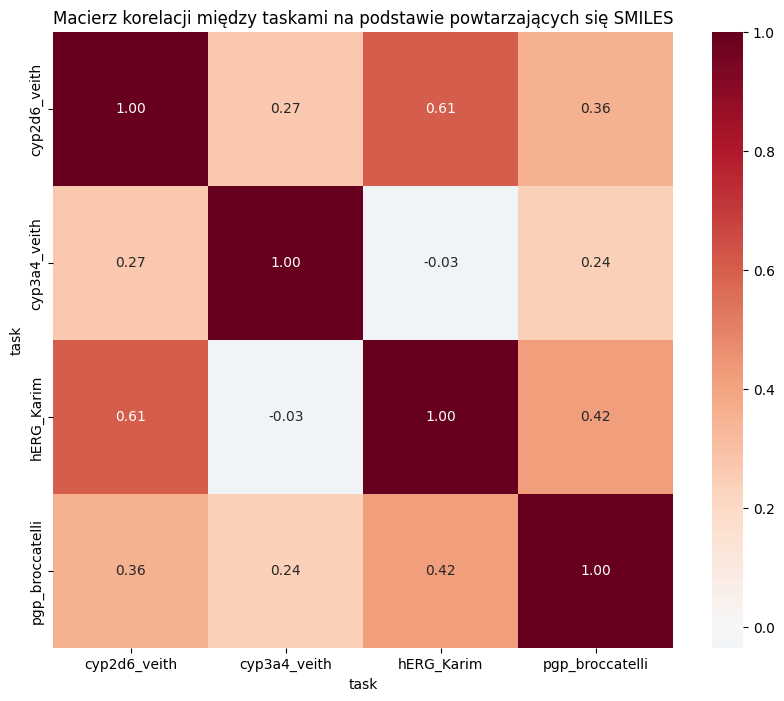

In [10]:
mask = df.groupby('smiles')['task'].transform('nunique') > 1
duplicated_rows = df[df.groupby('smiles')['task'].transform('nunique') > 1].sort_values('smiles')
corr_matrix = df_wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Macierz korelacji między taskami na podstawie powtarzających się SMILES')
plt.show()

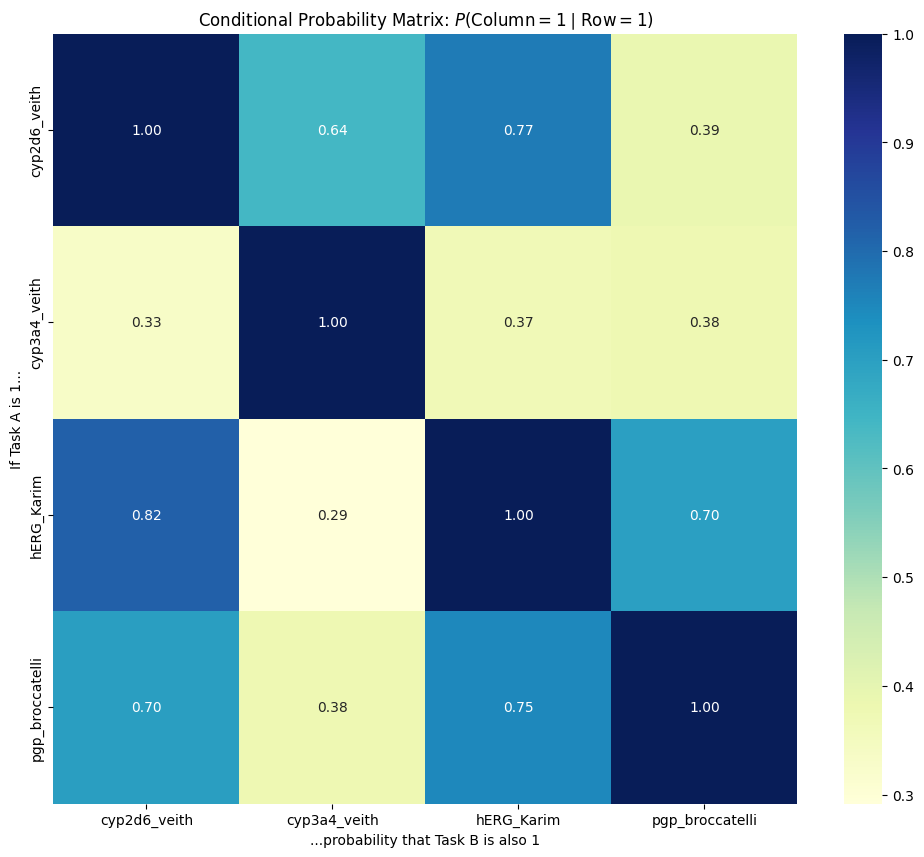

In [11]:
ones_mask = (df_wide == 1).astype(int)
intersection_11 = ones_mask.T @ ones_mask

valid_mask = df_wide.notna().astype(int)
intersection_1x = ones_mask.T @ valid_mask

cond_prob = intersection_11 / intersection_1x

plt.figure(figsize=(12, 10))
sns.heatmap(cond_prob, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Conditional Probability Matrix: $P(\\text{Column}=1 \\mid \\text{Row}=1)$")
plt.ylabel("If Task A is 1...")
plt.xlabel("...probability that Task B is also 1")
plt.show()

In [15]:
summary_df = random_forest_model.run_single_task_pipeline(df, tasks)
summary_df['SOTA acc'] = ['0.790±0.001', '0.916±0.000', ' 0.880±0.002', '0.938±0.002']
summary_df

,task,auc,acc,f1,SOTA acc
0,cyp2d6_veith,0.872269,0.870906,0.528512,0.790±0.001
1,cyp3a4_veith,0.885926,0.796837,0.739198,0.916±0.000
2,hERG_Karim,0.925830,0.854221,0.854167,0.880±0.002
3,pgp_broccatelli,0.928711,0.877049,0.875000,0.938±0.002


SOTA results from paper "Quantum Enhanced MTL ...".


In our model used RandomForestClassifier from scikit with 200 estimators.